In [1]:
# Importando bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # still useful for color palettes/style
import numpy as np

# Nominal

In [2]:
# Instanciando o gerador de números aleatórios para garantir reprodutibilidade
nums = np.array([410, 693, 405, 639])
cepas = ['Cepa A', 'Cepa B', 'Cepa C', 'Cepa D']
concentracoes = ['Concent A', 'Concent B', 'Concent C', 'Concent D']

dados_nom = np.append(
    np.append(
        np.array([cepas[0]]*nums[0]).reshape(nums[0], 1),
        np.array([cepas[1]]*nums[1]).reshape(nums[1], 1),
    ),
    np.append(
        np.array([cepas[2]]*nums[2]).reshape(nums[2], 1),
        np.array([cepas[3]]*nums[3]).reshape(nums[3], 1),
    )
).reshape(-1)
np.random.shuffle(dados_nom)

dados_concen = np.append(
    np.append(
        np.array([concentracoes[0]]*nums[0]).reshape(nums[0], 1),
        np.array([concentracoes[1]]*nums[1]).reshape(nums[1], 1),
    ),
    np.append(
        np.array([concentracoes[2]]*nums[2]).reshape(nums[2], 1),
        np.array([concentracoes[3]]*nums[3]).reshape(nums[3], 1),
    )
).reshape(-1)
np.random.shuffle(dados_concen)

dados_nominal = pd.DataFrame({"cepa": dados_nom, "concent": dados_concen}, index=["Pac "+f"{i}" for i in range(dados_nom.shape[0])])
dados_nominal.head()

,cepa,concent
Pac 0,Cepa B,Concent C
Pac 1,Cepa A,Concent B
Pac 2,Cepa B,Concent D
Pac 3,Cepa C,Concent D
Pac 4,Cepa B,Concent A


In [3]:
# Usando o método crosstab para criar uma tabela de contingência entre 'cepa' e 'concent'
pd.crosstab(dados_nominal['cepa'], dados_nominal['concent'])

concent,Concent A,Concent B,Concent C,Concent D
cepa,,,,
Cepa A,76,135,81,118
Cepa B,142,225,123,203
Cepa C,69,123,75,138
Cepa D,123,210,126,180


In [4]:
# Calculando a frequência absoluta simples e a frequência relativa simples para a variável 'cepa'
dados_nominal.value_counts("cepa").sort_index()
df_nominal = dados_nominal["cepa"].value_counts().sort_index()
df_nominal = df_nominal.to_frame()
df_nominal['Freq Relat Simp'] = dados_nominal.value_counts("cepa", normalize=True).sort_index()
df_nominal.rename(columns={"cepa": "Freq Absol Simp"}, inplace=True)
df_nominal = df_nominal.round(2)
df_nominal.loc["Total", ['Freq Absol Simp', "Freq Relat Simp"]] = df_nominal.sum()  # Add a total row
df_nominal

,Freq Absol Simp,Freq Relat Simp
Cepa A,410.0,0.19
Cepa B,693.0,0.32
Cepa C,405.0,0.19
Cepa D,639.0,0.30
Total,2147.0,1.00


In [5]:
# Indexando a DataFrame para excluir a linha "Total" e as colunas "Freq Absol Simp" e "Freq Relat Simp"
df_nominal.iloc[:-1, :]

,Freq Absol Simp,Freq Relat Simp
Cepa A,410.0,0.19
Cepa B,693.0,0.32
Cepa C,405.0,0.19
Cepa D,639.0,0.30


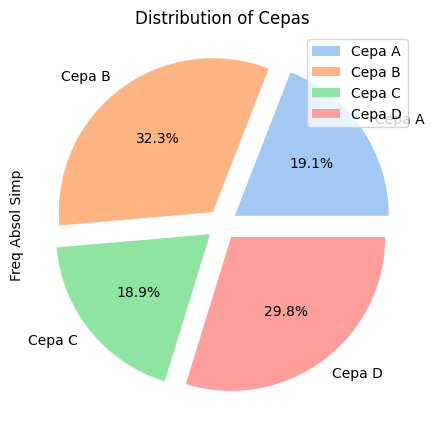

In [6]:
# Apply Seaborn style
sns.set_palette('pastel') 

# Plot directly from pandas
df_nominal.iloc[:-1, :].plot.pie(y=df_nominal.columns[0], autopct='%1.1f%%', figsize=(5, 5), explode=[0.1, 0.1, 0.1, 0.1])  # Explode all slices for better visibility
plt.title('Distribution of Cepas')
plt.show()

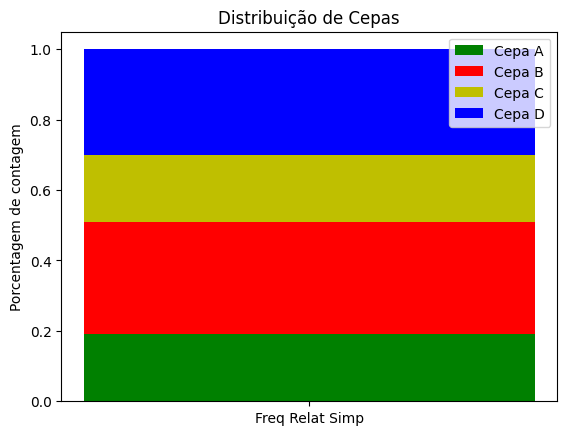

In [7]:
# Instanciando os valores para o gráfico de barras
coluna = df_nominal.columns[1]  # Assuming 'Freq Relat Simpl' is the second column
a, b, c, d, _ = df_nominal[coluna].values

# Plotando o gráfico de barras empilhadas
plt.bar(coluna, a, color='g')
plt.bar(coluna, b, color='r', bottom=a)
plt.bar(coluna, c, color='y', bottom=a+b)
plt.bar(coluna, d, color='b', bottom=a+b+c)
plt.legend(df_nominal[coluna].index)
plt.ylabel('Porcentagem de contagem')
plt.title('Distribuição de Cepas')
plt.show()

# Ordinal

In [8]:
def gerar_dados_concen(valores: list) -> pd.DataFrame:
    '''
        Gera um DataFrame com as frequências absolutas e relativas para 
        as concentrações.
            Args:
                valores (list): Uma lista de inteiros representando as
                                contagens para cada concentração.
            Returns:
                    pd.DataFrame: Um DataFrame contendo as frequências
                                absolutas e relativas para as concentrações.
    '''
    nums = np.array(valores)
    concentracoes = ['Concent A', 'Concent B', 'Concent C', 'Concent D']

    dados_concen = np.append(
        np.append(
            np.array([concentracoes[0]]*nums[0]).reshape(nums[0], 1),
            np.array([concentracoes[1]]*nums[1]).reshape(nums[1], 1),
        ),
        np.append(
            np.array([concentracoes[2]]*nums[2]).reshape(nums[2], 1),
            np.array([concentracoes[3]]*nums[3]).reshape(nums[3], 1),
        )
    ).reshape(-1)
    np.random.shuffle(dados_concen)

    dados_ordinal = pd.DataFrame(
                {"concent": dados_concen},
                index=["Pac "+f"{i}" for i in range(dados_concen.shape[0])]
    )
    dados_ordinal.value_counts("concent").sort_index()
    df_ordinal = dados_ordinal["concent"].value_counts().sort_index()
    df_ordinal = df_ordinal.to_frame()
    df_ordinal['Freq Relat Simp'] = dados_ordinal.value_counts(
                                                                "concent",
                                                                normalize=True
                                                            ).sort_index()
    df_ordinal.rename(columns={"concent": "Freq Absol Simp"}, inplace=True)
    df_ordinal.loc["Total", [
                                'Freq Absol Simp',
                                "Freq Relat Simp"
                            ]] = df_ordinal.sum()
    df_ordinal['Freq Absol Acum'] = df_ordinal['Freq Absol Simp'].cumsum()
    a = df_ordinal["Freq Absol Acum"] / df_ordinal.loc[
                                                        "Total",
                                                        "Freq Absol Simp"
                                                    ]
    df_ordinal['Freq Relat Acum'] = a
    df_ordinal.iloc[-1, [2, 3]] = np.nan
    df_ordinal = df_ordinal.round(2)
    return df_ordinal

In [9]:
# Gerando o DataFrame para as concentrações usando a função criada
df_ordinal = gerar_dados_concen(valores=[386, 799, 158, 935])
df_ordinal

,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum
Concent A,386.0,0.17,386.0,0.17
Concent B,799.0,0.35,1185.0,0.52
Concent C,158.0,0.07,1343.0,0.59
Concent D,935.0,0.41,2278.0,1.00
Total,2278.0,1.00,NaN,NaN


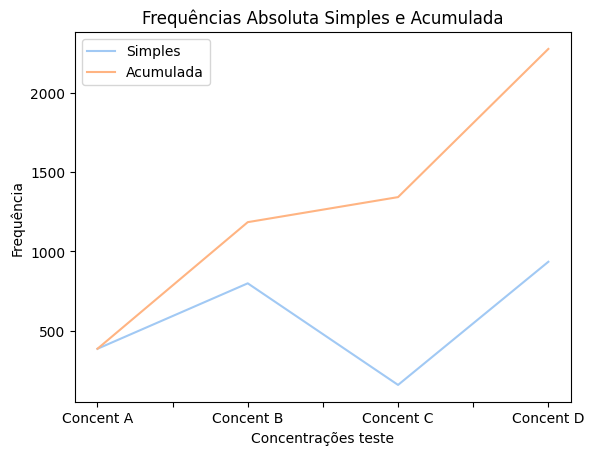

In [10]:
# Plotando as frequências absoluta simples e acumulada para as concentrações
df_ordinal.iloc[:-1][[df_ordinal.columns[0],df_ordinal.columns[2]]].plot()
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Absoluta Simples e Acumulada")
plt.legend(['Simples', 'Acumulada'])
plt.show()

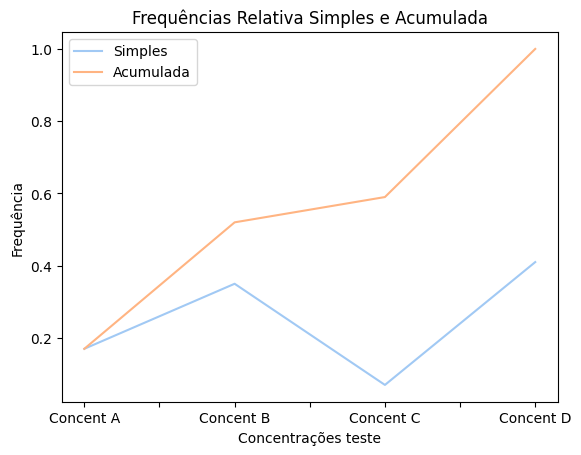

In [11]:
# Plotando as frequências relativa simples e acumulada para as concentrações
df_ordinal.iloc[:-1][[df_ordinal.columns[1],df_ordinal.columns[3]]].plot()
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Relativa Simples e Acumulada")
plt.legend(['Simples', 'Acumulada'])
plt.show()

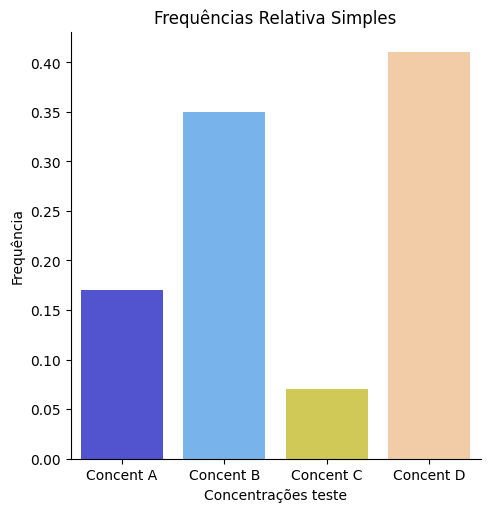

In [12]:
# Plotando as frequências relativa simples para as concentrações usando Seaborn
custom_palette = ["#3C3FE4", '#66B3FF', "#E4D943", '#FFCC99']  # Custom pastel colors
sns.catplot(
    kind='bar',
    x=list(df_ordinal['Freq Relat Simp'].index)[:-1],
    y='Freq Relat Simp',
    data=df_ordinal.iloc[:-1],
    palette=custom_palette
)
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Relativa Simples")
plt.show()

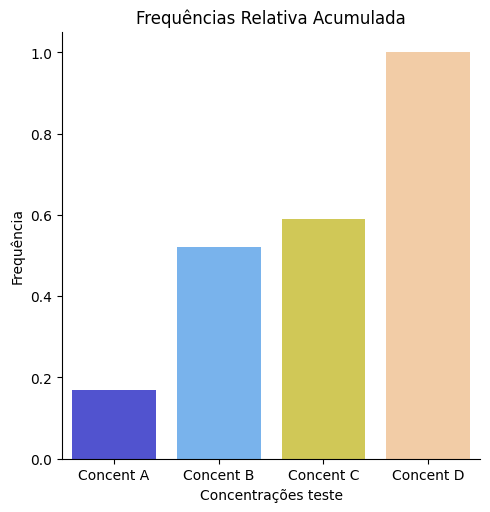

In [13]:
# Plotando as frequências relativa acumulada para as concentrações usando Seaborn
sns.catplot(
    kind='bar',
    x=list(df_ordinal['Freq Relat Acum'].index)[:-1],
    y='Freq Relat Acum',
    data=df_ordinal.iloc[:-1],
    palette=custom_palette
)
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Relativa Acumulada")

plt.show()

In [14]:
# Gerando um novo DataFrame para as concentrações usando a função criada
df_ordinal_II = gerar_dados_concen(valores=[306, 789, 263, 930])
df_ordinal_II['Teste'] = 'Teste II'
df_ordinal_II

,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Teste
Concent A,306.0,0.13,306.0,0.13,Teste II
Concent B,789.0,0.34,1095.0,0.48,Teste II
Concent C,263.0,0.11,1358.0,0.59,Teste II
Concent D,930.0,0.41,2288.0,1.00,Teste II
Total,2288.0,1.00,NaN,NaN,Teste II


In [15]:
# Concatenando os DataFrames para os dois testes e renomeando o índice
df_ordinal['Teste'] = 'Teste I'
drogs_data_grupo = pd.concat([df_ordinal, df_ordinal_II], axis=0).reset_index().rename(columns={'index': 'Concentração'})
drogs_data_grupo

,Concentração,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Teste
0,Concent A,386.0,0.17,386.0,0.17,Teste I
1,Concent B,799.0,0.35,1185.0,0.52,Teste I
2,Concent C,158.0,0.07,1343.0,0.59,Teste I
3,Concent D,935.0,0.41,2278.0,1.00,Teste I
4,Total,2278.0,1.00,NaN,NaN,Teste I
5,Concent A,306.0,0.13,306.0,0.13,Teste II
6,Concent B,789.0,0.34,1095.0,0.48,Teste II
7,Concent C,263.0,0.11,1358.0,0.59,Teste II
8,Concent D,930.0,0.41,2288.0,1.00,Teste II
9,Total,2288.0,1.00,NaN,NaN,Teste II


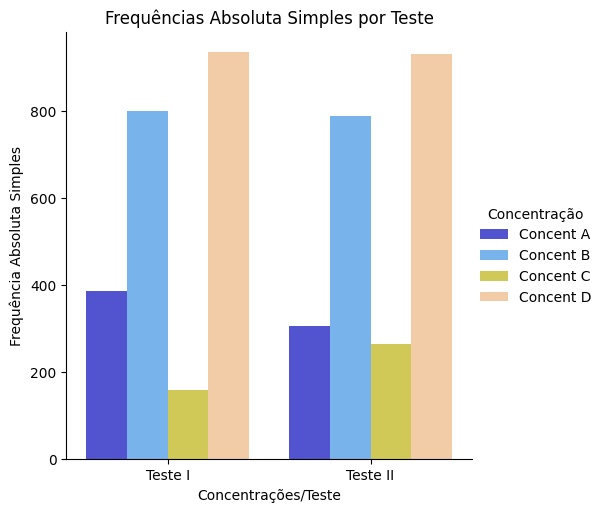

In [16]:
# Plotando as frequências absoluta simples para os dois testes usando Seaborn
sns.catplot(
    kind='bar',
    x='Teste',
    y='Freq Absol Simp',
    hue='Concentração',
    palette=custom_palette,
    data=drogs_data_grupo.dropna(),
)
plt.ylabel("Frequência Absoluta Simples")
plt.title("Frequências Absoluta Simples por Teste")
plt.xlabel("Concentrações/Teste")
plt.show()

In [17]:
# Concatenando os DataFrames para os dois testes e renomeando o índice
df_ordinal_III = gerar_dados_concen(valores=[406, 489, 363, 930])
df_ordinal_III['Teste'] = 'Teste I'
df_ordinal_IV = gerar_dados_concen(valores=[406, 789, 363, 730])
df_ordinal_IV['Teste'] = 'Teste II'

drogs_data_grupo_I = pd.concat([df_ordinal_III, df_ordinal_IV], axis=0).reset_index().rename(columns={'index': 'Concentração'})
drogs_data_grupo['Replica'] = 'Repl I'
drogs_data_grupo_I['Replica'] = 'Repl II'
drogs_data_grupo_I

,Concentração,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Teste,Replica
0,Concent A,406.0,0.19,406.0,0.19,Teste I,Repl II
1,Concent B,489.0,0.22,895.0,0.41,Teste I,Repl II
2,Concent C,363.0,0.17,1258.0,0.57,Teste I,Repl II
3,Concent D,930.0,0.43,2188.0,1.00,Teste I,Repl II
4,Total,2188.0,1.00,NaN,NaN,Teste I,Repl II
5,Concent A,406.0,0.18,406.0,0.18,Teste II,Repl II
6,Concent B,789.0,0.34,1195.0,0.52,Teste II,Repl II
7,Concent C,363.0,0.16,1558.0,0.68,Teste II,Repl II
8,Concent D,730.0,0.32,2288.0,1.00,Teste II,Repl II
9,Total,2288.0,1.00,NaN,NaN,Teste II,Repl II


In [18]:
drogs_data_grupo

,Concentração,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Teste,Replica
0,Concent A,386.0,0.17,386.0,0.17,Teste I,Repl I
1,Concent B,799.0,0.35,1185.0,0.52,Teste I,Repl I
2,Concent C,158.0,0.07,1343.0,0.59,Teste I,Repl I
3,Concent D,935.0,0.41,2278.0,1.00,Teste I,Repl I
4,Total,2278.0,1.00,NaN,NaN,Teste I,Repl I
5,Concent A,306.0,0.13,306.0,0.13,Teste II,Repl I
6,Concent B,789.0,0.34,1095.0,0.48,Teste II,Repl I
7,Concent C,263.0,0.11,1358.0,0.59,Teste II,Repl I
8,Concent D,930.0,0.41,2288.0,1.00,Teste II,Repl I
9,Total,2288.0,1.00,NaN,NaN,Teste II,Repl I


In [19]:
# Concatenando os DataFrames para os dois testes e renomeando o índice
drogs_data_grupo_teste = pd.concat([drogs_data_grupo, drogs_data_grupo_I], axis=0).dropna()
drogs_data_grupo_teste

,Concentração,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Teste,Replica
0,Concent A,386.0,0.17,386.0,0.17,Teste I,Repl I
1,Concent B,799.0,0.35,1185.0,0.52,Teste I,Repl I
2,Concent C,158.0,0.07,1343.0,0.59,Teste I,Repl I
3,Concent D,935.0,0.41,2278.0,1.00,Teste I,Repl I
5,Concent A,306.0,0.13,306.0,0.13,Teste II,Repl I
6,Concent B,789.0,0.34,1095.0,0.48,Teste II,Repl I
7,Concent C,263.0,0.11,1358.0,0.59,Teste II,Repl I
8,Concent D,930.0,0.41,2288.0,1.00,Teste II,Repl I
0,Concent A,406.0,0.19,406.0,0.19,Teste I,Repl II
1,Concent B,489.0,0.22,895.0,0.41,Teste I,Repl II


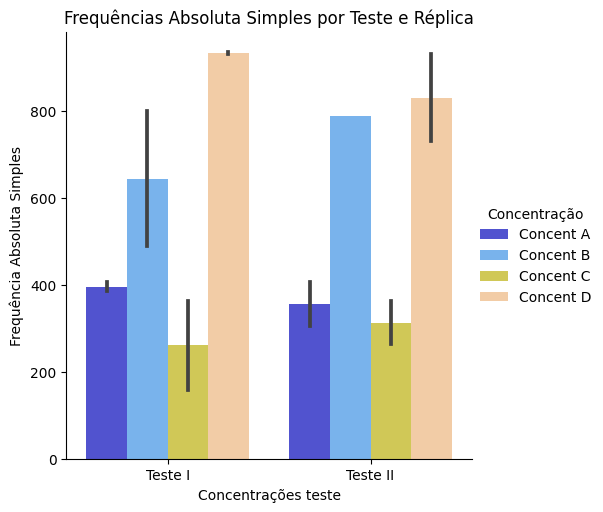

In [20]:
# Plotando as frequências absoluta simples para os dois testes e réplicas usando Seaborn
sns.catplot(
    kind='bar',
    x='Teste',
    y='Freq Absol Simp',
    hue='Concentração',
    palette=custom_palette,
    data=drogs_data_grupo_teste,
)
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência Absoluta Simples")
plt.title("Frequências Absoluta Simples por Teste e Réplica")
plt.show()